# 4. Model Building
## Train, evaluate, confusion matrix, save .pkl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import joblib

DATA_PATH = Path("../data/water_potability.csv")
MODELS_DIR = Path("../models")
FEATURE_NAMES = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate", "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]
df = pd.read_csv(DATA_PATH)
for col in FEATURE_NAMES:
    df[col] = df[col].fillna(df[col].median())

In [2]:
X = df[FEATURE_NAMES]
y = df["Potability"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Train Random Forest

In [3]:
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=["Not Potable", "Potable"]))

Accuracy: 0.6692073170731707
F1 (weighted): 0.6210512394619396
              precision    recall  f1-score   support

 Not Potable       0.66      0.93      0.77       400
     Potable       0.71      0.26      0.38       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



## Confusion Matrix (heatmap)

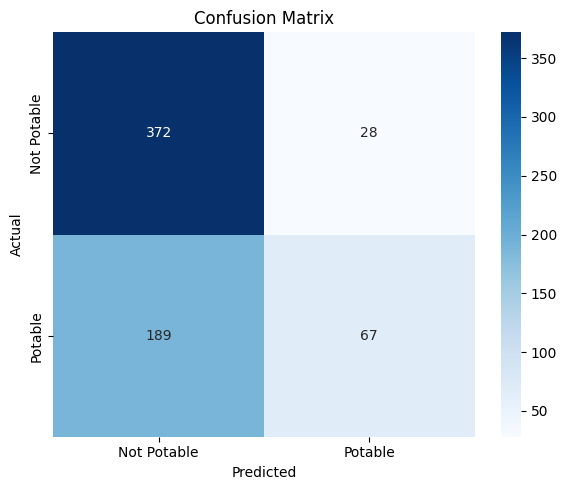

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Potable", "Potable"], yticklabels=["Not Potable", "Potable"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature importance heatmap (as bar)

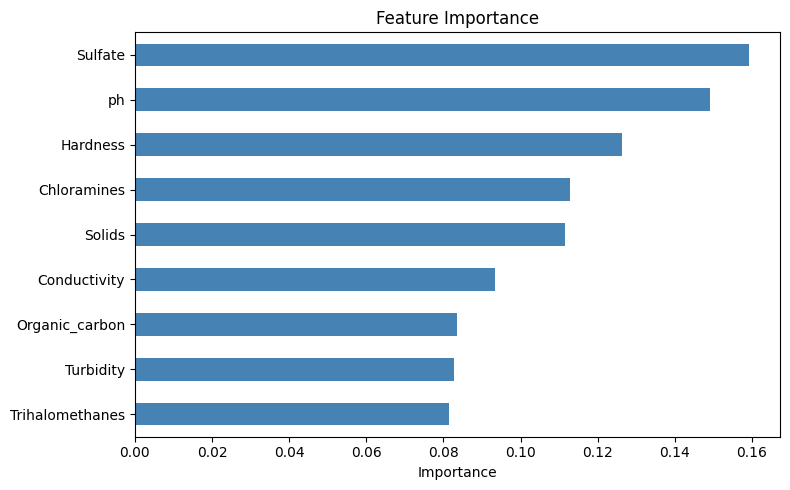

In [5]:
imp = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Cross-validation

In [6]:
scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring="accuracy")
print("CV Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

CV Accuracy: 0.660 (+/- 0.025)


## Save model and scaler as .pkl

In [7]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODELS_DIR / "water_quality_model.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
print("Saved water_quality_model.pkl and scaler.pkl")

Saved water_quality_model.pkl and scaler.pkl
